# 01 Data Collection, Audit And EDA

Scalony notebook obejmujacy pobieranie danych, audyt sesji, pierwsze EDA i wstepne rozpoznanie potencjalnych zbiorow.


## Source: `01_setup.ipynb`


## Importy

In [3]:
from pathlib import Path
import warnings

import fastf1
import pandas as pd
import numpy as np

warnings.filterwarnings("ignore")

DATA_DIR = Path("data")
EXPORT_DIR = Path("exports")
CACHE_DIR = Path("f1_cache")

DATA_DIR.mkdir(exist_ok=True)
EXPORT_DIR.mkdir(exist_ok=True)
CACHE_DIR.mkdir(exist_ok=True)

fastf1.Cache.enable_cache(str(CACHE_DIR))

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

## Helpery

In [4]:
def timed_to_seconds(series: pd.Series) -> pd.Series:
    """Convert timedelta-like series to float seconds."""
    return pd.to_timedelta(series, errors="coerce").dt.total_seconds()


def safe_col_subset(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    existing = [c for c in cols if c in df.columns]
    return df[existing].copy()


def export_csv(df: pd.DataFrame, name: str) -> Path:
    path = EXPORT_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    return path

## Check co jest w bazie

In [5]:
YEARS_TO_CHECK = [2023, 2024, 2025]

schedule_frames = []

for year in YEARS_TO_CHECK:
    try:
        schedule = fastf1.get_event_schedule(year, include_testing=False)
        schedule = schedule.copy()
        schedule["Season"] = year
        schedule_frames.append(schedule)
        print(f"{year}: loaded {len(schedule)} events")
    except Exception as e:
        print(f"{year}: FAILED -> {type(e).__name__}: {e}")

event_schedule_df = pd.concat(schedule_frames, ignore_index=True) if schedule_frames else pd.DataFrame()
event_schedule_df.head()

2023: loaded 22 events
2024: loaded 24 events
2025: loaded 24 events


,RoundNumber,Country,Location,OfficialEventName,EventDate,EventName,EventFormat,Session1,Session1Date,Session1DateUtc,Session2,Session2Date,Session2DateUtc,Session3,Session3Date,Session3DateUtc,Session4,Session4Date,Session4DateUtc,Session5,Session5Date,Session5DateUtc,F1ApiSupport,Season
0,1,Bahrain,Sakhir,FORMULA 1 GULF AIR BAHRAIN GRAND PRIX 2023,2023-03-05,Bahrain Grand Prix,conventional,Practice 1,2023-03-03 14:30:00+03:00,2023-03-03 11:30:00,Practice 2,2023-03-03 18:00:00+03:00,2023-03-03 15:00:00,Practice 3,2023-03-04 14:30:00+03:00,2023-03-04 11:30:00,Qualifying,2023-03-04 18:00:00+03:00,2023-03-04 15:00:00,Race,2023-03-05 18:00:00+03:00,2023-03-05 15:00:00,True,2023
1,2,Saudi Arabia,Jeddah,FORMULA 1 STC SAUDI ARABIAN GRAND PRIX 2023,2023-03-19,Saudi Arabian Grand Prix,conventional,Practice 1,2023-03-17 16:30:00+03:00,2023-03-17 13:30:00,Practice 2,2023-03-17 20:00:00+03:00,2023-03-17 17:00:00,Practice 3,2023-03-18 16:30:00+03:00,2023-03-18 13:30:00,Qualifying,2023-03-18 20:00:00+03:00,2023-03-18 17:00:00,Race,2023-03-19 20:00:00+03:00,2023-03-19 17:00:00,True,2023
2,3,Australia,Melbourne,FORMULA 1 ROLEX AUSTRALIAN GRAND PRIX 2023,2023-04-02,Australian Grand Prix,conventional,Practice 1,2023-03-31 12:30:00+10:00,2023-03-31 02:30:00,Practice 2,2023-03-31 16:00:00+10:00,2023-03-31 06:00:00,Practice 3,2023-04-01 12:30:00+10:00,2023-04-01 02:30:00,Qualifying,2023-04-01 16:00:00+10:00,2023-04-01 06:00:00,Race,2023-04-02 15:00:00+10:00,2023-04-02 05:00:00,True,2023
3,4,Azerbaijan,Baku,FORMULA 1 AZERBAIJAN GRAND PRIX 2023,2023-04-30,Azerbaijan Grand Prix,sprint_shootout,Practice 1,2023-04-28 13:30:00+04:00,2023-04-28 09:30:00,Qualifying,2023-04-28 17:00:00+04:00,2023-04-28 13:00:00,Sprint Shootout,2023-04-29 12:30:00+04:00,2023-04-29 08:30:00,Sprint,2023-04-29 17:30:00+04:00,2023-04-29 13:30:00,Race,2023-04-30 15:00:00+04:00,2023-04-30 11:00:00,True,2023
4,5,United States,Miami,FORMULA 1 CRYPTO.COM MIAMI GRAND PRIX 2023,2023-05-07,Miami Grand Prix,conventional,Practice 1,2023-05-05 14:00:00-04:00,2023-05-05 18:00:00,Practice 2,2023-05-05 17:30:00-04:00,2023-05-05 21:30:00,Practice 3,2023-05-06 12:30:00-04:00,2023-05-06 16:30:00,Qualifying,2023-05-06 16:00:00-04:00,2023-05-06 20:00:00,Race,2023-05-07 15:30:00-04:00,2023-05-07 19:30:00,True,2023


In [6]:
print("Schedule columns:")
print(sorted(event_schedule_df.columns.tolist()))

export_csv(event_schedule_df, "event_schedule_audit")
event_schedule_df[["Season", "RoundNumber", "EventName", "EventDate"]].head(20)

Schedule columns:
['Country', 'EventDate', 'EventFormat', 'EventName', 'F1ApiSupport', 'Location', 'OfficialEventName', 'RoundNumber', 'Season', 'Session1', 'Session1Date', 'Session1DateUtc', 'Session2', 'Session2Date', 'Session2DateUtc', 'Session3', 'Session3Date', 'Session3DateUtc', 'Session4', 'Session4Date', 'Session4DateUtc', 'Session5', 'Session5Date', 'Session5DateUtc']


,Season,RoundNumber,EventName,EventDate
0,2023,1,Bahrain Grand Prix,2023-03-05
1,2023,2,Saudi Arabian Grand Prix,2023-03-19
2,2023,3,Australian Grand Prix,2023-04-02
3,2023,4,Azerbaijan Grand Prix,2023-04-30
4,2023,5,Miami Grand Prix,2023-05-07
5,2023,6,Monaco Grand Prix,2023-05-28
6,2023,7,Spanish Grand Prix,2023-06-04
7,2023,8,Canadian Grand Prix,2023-06-18
8,2023,9,Austrian Grand Prix,2023-07-02
9,2023,10,British Grand Prix,2023-07-09


In [7]:
audit_rows = []

for _, row in event_schedule_df.iterrows():
    year = int(row["Season"])
    round_number = int(row["RoundNumber"])
    event_name = row["EventName"]

    try:
        session = fastf1.get_session(year, round_number, "Q")
        session.load(
            laps=True,
            telemetry=False,
            weather=True,
            messages=False
        )

        laps = session.laps.copy()
        results = session.results.copy() if session.results is not None else pd.DataFrame()

        audit_row = {
            "season": year,
            "round": round_number,
            "event_name": event_name,
            "session_name": getattr(session, "name", None),
            "session_date": getattr(session, "date", None),
            "country": getattr(session.event, "Country", None) if hasattr(session, "event") else None,
            "location": getattr(session.event, "Location", None) if hasattr(session, "event") else None,
            "official_event_name": getattr(session.event, "OfficialEventName", None) if hasattr(session, "event") else None,
            "n_results_rows": len(results),
            "n_laps_rows": len(laps),
            "n_unique_drivers_in_laps": laps["Driver"].nunique() if "Driver" in laps.columns else np.nan,
            "lap_columns_count": len(laps.columns),
            "results_columns_count": len(results.columns),
            "has_compound": "Compound" in laps.columns,
            "has_tyre_life": "TyreLife" in laps.columns,
            "has_track_status": "TrackStatus" in laps.columns,
            "has_is_personal_best": "IsPersonalBest" in laps.columns,
            "has_lap_time": "LapTime" in laps.columns,
            "has_sector1": "Sector1Time" in laps.columns,
            "has_sector2": "Sector2Time" in laps.columns,
            "has_sector3": "Sector3Time" in laps.columns,
        }

        # Weather summary if available
        try:
            weather = session.weather_data.copy()
            audit_row["n_weather_rows"] = len(weather)
            audit_row["weather_columns_count"] = len(weather.columns)
            if "Rainfall" in weather.columns:
                audit_row["max_rainfall"] = pd.to_numeric(weather["Rainfall"], errors="coerce").max()
            else:
                audit_row["max_rainfall"] = np.nan
        except Exception:
            audit_row["n_weather_rows"] = np.nan
            audit_row["weather_columns_count"] = np.nan
            audit_row["max_rainfall"] = np.nan

        audit_rows.append(audit_row)
        print(f"OK  {year} R{round_number:02d} {event_name}")

    except Exception as e:
        audit_rows.append({
            "season": year,
            "round": round_number,
            "event_name": event_name,
            "session_name": "Q",
            "load_error_type": type(e).__name__,
            "load_error_msg": str(e)
        })
        print(f"ERR {year} R{round_number:02d} {event_name} -> {type(e).__name__}: {e}")

session_audit_df = pd.DataFrame(audit_rows)
session_audit_df.head()

core           INFO 	Loading data for Bahrain Grand Prix - Qualifying [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 

OK  2023 R01 Bahrain Grand Prix


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for timing_app_data. Loading data...
_api           INFO 	Fetching timing app data...
req            INFO 	Data has been written to

OK  2023 R02 Saudi Arabian Grand Prix


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for timing_app_data. Loading data...
_api           INFO 	Fetching timing app data...
req            INFO 	Data has been written to

...

core           INFO 	Loading data for Qatar Grand Prix - Qualifying [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...


ERR 2025 R22 Las Vegas Grand Prix -> RateLimitExceededError: any API: 500 calls/h


core           INFO 	Loading data for Abu Dhabi Grand Prix - Qualifying [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...


ERR 2025 R23 Qatar Grand Prix -> RateLimitExceededError: any API: 500 calls/h
ERR 2025 R24 Abu Dhabi Grand Prix -> RateLimitExceededError: any API: 500 calls/h


,season,round,event_name,session_name,session_date,country,location,official_event_name,n_results_rows,n_laps_rows,n_unique_drivers_in_laps,lap_columns_count,results_columns_count,has_compound,has_tyre_life,has_track_status,has_is_personal_best,has_lap_time,has_sector1,has_sector2,has_sector3,n_weather_rows,weather_columns_count,max_rainfall,load_error_type,load_error_msg
0,2023,1,Bahrain Grand Prix,Qualifying,2023-03-04 15:00:00,Bahrain,Sakhir,FORMULA 1 GULF AIR BAHRAIN GRAND PRIX 2023,20.0,254.0,20.0,31.0,22.0,True,True,True,True,True,True,True,True,95.0,8.0,False,NaN,NaN
1,2023,2,Saudi Arabian Grand Prix,Qualifying,2023-03-18 17:00:00,Saudi Arabia,Jeddah,FORMULA 1 STC SAUDI ARABIAN GRAND PRIX 2023,20.0,329.0,20.0,31.0,22.0,True,True,True,True,True,True,True,True,80.0,8.0,False,NaN,NaN
2,2023,3,Australian Grand Prix,Qualifying,2023-04-01 06:00:00,Australia,Melbourne,FORMULA 1 ROLEX AUSTRALIAN GRAND PRIX 2023,20.0,419.0,20.0,31.0,22.0,True,True,True,True,True,True,True,True,95.0,8.0,True,NaN,NaN
3,2023,4,Azerbaijan Grand Prix,Qualifying,2023-04-28 13:00:00,Azerbaijan,Baku,FORMULA 1 AZERBAIJAN GRAND PRIX 2023,20.0,356.0,20.0,31.0,22.0,True,True,True,True,True,True,True,True,106.0,8.0,False,NaN,NaN
4,2023,5,Miami Grand Prix,Qualifying,2023-05-06 20:00:00,United States,Miami,FORMULA 1 CRYPTO.COM MIAMI GRAND PRIX 2023,20.0,304.0,20.0,31.0,22.0,True,True,True,True,True,True,True,True,87.0,8.0,False,NaN,NaN


In [8]:
# Run this cell later (for example after ~1 hour) to retry only sessions
# that failed due to API rate limiting in cell 6.

rate_limited_mask = session_audit_df["load_error_type"].eq("RateLimitExceededError")
remaining_rate_limited = session_audit_df[rate_limited_mask].copy()

print(f"Rate-limited sessions to retry: {len(remaining_rate_limited)}")
display(remaining_rate_limited[["season", "round", "event_name", "load_error_type"]])

retry_rows = []

for _, row in remaining_rate_limited.iterrows():
    year = int(row["season"])
    round_number = int(row["round"])
    event_name = row["event_name"]

    try:
        session = fastf1.get_session(year, round_number, "Q")
        session.load(
            laps=True,
            telemetry=False,
            weather=True,
            messages=False
        )

        laps = session.laps.copy()
        results = session.results.copy() if session.results is not None else pd.DataFrame()

        retry_row = {
            "season": year,
            "round": round_number,
            "event_name": event_name,
            "session_name": getattr(session, "name", None),
            "session_date": getattr(session, "date", None),
            "country": getattr(session.event, "Country", None) if hasattr(session, "event") else None,
            "location": getattr(session.event, "Location", None) if hasattr(session, "event") else None,
            "official_event_name": getattr(session.event, "OfficialEventName", None) if hasattr(session, "event") else None,
            "n_results_rows": len(results),
            "n_laps_rows": len(laps),
            "n_unique_drivers_in_laps": laps["Driver"].nunique() if "Driver" in laps.columns else np.nan,
            "lap_columns_count": len(laps.columns),
            "results_columns_count": len(results.columns),
            "has_compound": "Compound" in laps.columns,
            "has_tyre_life": "TyreLife" in laps.columns,
            "has_track_status": "TrackStatus" in laps.columns,
            "has_is_personal_best": "IsPersonalBest" in laps.columns,
            "has_lap_time": "LapTime" in laps.columns,
            "has_sector1": "Sector1Time" in laps.columns,
            "has_sector2": "Sector2Time" in laps.columns,
            "has_sector3": "Sector3Time" in laps.columns,
            "load_error_type": np.nan,
            "load_error_msg": np.nan,
        }

        try:
            weather = session.weather_data.copy()
            retry_row["n_weather_rows"] = len(weather)
            retry_row["weather_columns_count"] = len(weather.columns)
            if "Rainfall" in weather.columns:
                retry_row["max_rainfall"] = pd.to_numeric(weather["Rainfall"], errors="coerce").max()
            else:
                retry_row["max_rainfall"] = np.nan
        except Exception:
            retry_row["n_weather_rows"] = np.nan
            retry_row["weather_columns_count"] = np.nan
            retry_row["max_rainfall"] = np.nan

        retry_rows.append(retry_row)
        print(f"OK  {year} R{round_number:02d} {event_name}")

    except Exception as e:
        retry_rows.append({
            "season": year,
            "round": round_number,
            "event_name": event_name,
            "session_name": "Q",
            "load_error_type": type(e).__name__,
            "load_error_msg": str(e)
        })
        print(f"ERR {year} R{round_number:02d} {event_name} -> {type(e).__name__}: {e}")

retry_df = pd.DataFrame(retry_rows)

# Remove the old rate-limited rows and replace them with retried versions
session_audit_df = pd.concat(
    [
        session_audit_df[~rate_limited_mask].copy(),
        retry_df
    ],
    ignore_index=True
).sort_values(["season", "round"]).reset_index(drop=True)

export_csv(session_audit_df, "qualifying_session_audit")

print("\nUpdated export:")
print("- exports/qualifying_session_audit.csv")

Rate-limited sessions to retry: 8


,season,round,event_name,load_error_type
62,2025,17,Azerbaijan Grand Prix,RateLimitExceededError
63,2025,18,Singapore Grand Prix,RateLimitExceededError
64,2025,19,United States Grand Prix,RateLimitExceededError
65,2025,20,Mexico City Grand Prix,RateLimitExceededError
66,2025,21,São Paulo Grand Prix,RateLimitExceededError
67,2025,22,Las Vegas Grand Prix,RateLimitExceededError
68,2025,23,Qatar Grand Prix,RateLimitExceededError
69,2025,24,Abu Dhabi Grand Prix,RateLimitExceededError


core           INFO 	Loading data for Azerbaijan Grand Prix - Qualifying [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            IN

OK  2025 R17 Azerbaijan Grand Prix


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for timing_app_data. Loading data...
_api           INFO 	Fetching timing app data...
req            INFO 	Data has been written to

...

OK  2025 R22 Las Vegas Grand Prix


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for timing_app_data. Loading data...
_api           INFO 	Fetching timing app data...
req            INFO 	Data has been written to

OK  2025 R23 Qatar Grand Prix


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for timing_app_data. Loading data...
_api           INFO 	Fetching timing app data...
req            INFO 	Data has been written to

OK  2025 R24 Abu Dhabi Grand Prix

Updated export:
- exports/qualifying_session_audit.csv


In [9]:
summary_by_season = (
    session_audit_df
    .assign(load_ok=lambda d: d["load_error_type"].isna())
    .groupby("season", dropna=False)
    .agg(
        sessions_checked=("round", "count"),
        sessions_loaded=("load_ok", "sum"),
        total_laps_rows=("n_laps_rows", "sum"),
        mean_laps_rows=("n_laps_rows", "mean"),
        mean_unique_drivers=("n_unique_drivers_in_laps", "mean"),
        sessions_with_compound=("has_compound", "sum"),
        sessions_with_tyre_life=("has_tyre_life", "sum"),
        sessions_with_track_status=("has_track_status", "sum"),
        sessions_with_personal_best=("has_is_personal_best", "sum"),
    )
    .reset_index()
)

summary_by_season

,season,sessions_checked,sessions_loaded,total_laps_rows,mean_laps_rows,mean_unique_drivers,sessions_with_compound,sessions_with_tyre_life,sessions_with_track_status,sessions_with_personal_best
0,2023,22,22,7419.0,337.227273,20.000000,22,22,22,22
1,2024,24,24,7590.0,316.250000,19.916667,24,24,24,24
2,2025,24,24,7456.0,310.666667,19.958333,24,24,24,24


In [10]:
export_csv(session_audit_df, "qualifying_session_audit")
export_csv(summary_by_season, "qualifying_session_audit_summary_by_season")

print("Exported:")
print("- exports/qualifying_session_audit.csv")
print("- exports/qualifying_session_audit_summary_by_season.csv")

Exported:
- exports/qualifying_session_audit.csv
- exports/qualifying_session_audit_summary_by_season.csv


In [11]:
good_sessions = session_audit_df[session_audit_df["load_error_type"].isna()].copy()
good_sessions = good_sessions.sort_values(["season", "round"]).reset_index(drop=True)

good_sessions[["season", "round", "event_name", "n_laps_rows", "n_unique_drivers_in_laps"]].head(10)

,season,round,event_name,n_laps_rows,n_unique_drivers_in_laps
0,2023,1,Bahrain Grand Prix,254.0,20.0
1,2023,2,Saudi Arabian Grand Prix,329.0,20.0
2,2023,3,Australian Grand Prix,419.0,20.0
3,2023,4,Azerbaijan Grand Prix,356.0,20.0
4,2023,5,Miami Grand Prix,304.0,20.0
5,2023,6,Monaco Grand Prix,420.0,20.0
6,2023,7,Spanish Grand Prix,337.0,20.0
7,2023,8,Canadian Grand Prix,421.0,20.0
8,2023,9,Austrian Grand Prix,377.0,20.0
9,2023,10,British Grand Prix,386.0,20.0


In [12]:
TEST_YEAR = int(good_sessions.loc[0, "season"])
TEST_ROUND = int(good_sessions.loc[0, "round"])

session = fastf1.get_session(TEST_YEAR, TEST_ROUND, "Q")
session.load(laps=True, telemetry=True, weather=True, messages=False)

laps_df = session.laps.copy()
results_df = session.results.copy()
weather_df = session.weather_data.copy()

print("RESULTS COLUMNS:")
print(sorted(results_df.columns.tolist()))
print("\nLAPS COLUMNS:")
print(sorted(laps_df.columns.tolist()))
print("\nWEATHER COLUMNS:")
print(sorted(weather_df.columns.tolist()))

core           INFO 	Loading data for Bahrain Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	No cached data found for car_data. Loading data...
_api           INFO 	Fetching car data...
_api           INFO 	Parsing car data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for position_data. Loading data...
_api           INFO 	Fetching position data...
_api           INFO 	Parsing position data...
req            INFO 	Data has been written to cache!
req            INFO 	Using cached data for weather_data
core           INFO 	Finishe

RESULTS COLUMNS:
['Abbreviation', 'BroadcastName', 'ClassifiedPosition', 'CountryCode', 'DriverId', 'DriverNumber', 'FirstName', 'FullName', 'GridPosition', 'HeadshotUrl', 'Laps', 'LastName', 'Points', 'Position', 'Q1', 'Q2', 'Q3', 'Status', 'TeamColor', 'TeamId', 'TeamName', 'Time']

LAPS COLUMNS:
['Compound', 'Deleted', 'DeletedReason', 'Driver', 'DriverNumber', 'FastF1Generated', 'FreshTyre', 'IsAccurate', 'IsPersonalBest', 'LapNumber', 'LapStartDate', 'LapStartTime', 'LapTime', 'PitInTime', 'PitOutTime', 'Position', 'Sector1SessionTime', 'Sector1Time', 'Sector2SessionTime', 'Sector2Time', 'Sector3SessionTime', 'Sector3Time', 'SpeedFL', 'SpeedI1', 'SpeedI2', 'SpeedST', 'Stint', 'Team', 'Time', 'TrackStatus', 'TyreLife']

WEATHER COLUMNS:
['AirTemp', 'Humidity', 'Pressure', 'Rainfall', 'Time', 'TrackTemp', 'WindDirection', 'WindSpeed']


In [13]:
# pick a representative personal-best lap if possible
candidate_laps = laps_df.copy()

if "IsPersonalBest" in candidate_laps.columns:
    candidate_laps = candidate_laps[candidate_laps["IsPersonalBest"] == True]

candidate_laps = candidate_laps.dropna(subset=["LapTime"]) if "LapTime" in candidate_laps.columns else candidate_laps

lap = candidate_laps.sort_values("LapTime").iloc[0]
lap

Time                      0 days 01:23:54.472000
Driver                                       VER
DriverNumber                                   1
LapTime                   0 days 00:01:29.708000
LapNumber                                   14.0
Stint                                        6.0
PitOutTime                                   NaT
PitInTime                                    NaT
Sector1Time               0 days 00:00:28.736000
Sector2Time               0 days 00:00:38.514000
Sector3Time               0 days 00:00:22.458000
Sector1SessionTime        0 days 01:22:53.500000
Sector2SessionTime        0 days 01:23:32.014000
Sector3SessionTime        0 days 01:23:54.472000
SpeedI1                                    241.0
SpeedI2                                    271.0
SpeedFL                                    288.0
SpeedST                                    321.0
IsPersonalBest                              True
Compound                                    SOFT
TyreLife            

In [14]:
car_data = lap.get_car_data().copy()
pos_data = lap.get_pos_data().copy()

print("CAR DATA COLUMNS:")
print(sorted(car_data.columns.tolist()))
print(car_data.head())

print("\nPOSITION DATA COLUMNS:")
print(sorted(pos_data.columns.tolist()))
print(pos_data.head())

CAR DATA COLUMNS:
['Brake', 'DRS', 'Date', 'RPM', 'SessionTime', 'Source', 'Speed', 'Throttle', 'Time', 'nGear']
                     Date      RPM  Speed  nGear  Throttle  Brake  DRS Source                   Time            SessionTime
0 2023-03-04 16:07:26.056  10575.0  296.0      8     100.0  False   12    car 0 days 00:00:00.295000 0 days 01:22:25.059000
1 2023-03-04 16:07:26.377  10695.0  298.0      8     100.0  False   12    car 0 days 00:00:00.616000 0 days 01:22:25.380000
2 2023-03-04 16:07:26.777  10759.0  302.0      8     100.0  False   12    car 0 days 00:00:01.016000 0 days 01:22:25.780000
3 2023-03-04 16:07:27.177  10853.0  305.0      8     100.0  False   12    car 0 days 00:00:01.416000 0 days 01:22:26.180000
4 2023-03-04 16:07:27.377  10909.0  307.0      8     100.0  False   12    car 0 days 00:00:01.616000 0 days 01:22:26.380000

POSITION DATA COLUMNS:
['Date', 'SessionTime', 'Source', 'Status', 'Time', 'X', 'Y', 'Z']
                     Date   Status      X       Y   

In [15]:
telemetry_audit = {
    "season": TEST_YEAR,
    "round": TEST_ROUND,
    "event_name": session.event["EventName"] if "EventName" in session.event.index else None,
    "driver": lap["Driver"] if "Driver" in lap.index else None,
    "lap_number": lap["LapNumber"] if "LapNumber" in lap.index else None,
    "lap_time_sec": timed_to_seconds(pd.Series([lap["LapTime"]])).iloc[0] if "LapTime" in lap.index else np.nan,
    "car_rows": len(car_data),
    "pos_rows": len(pos_data),
    "car_columns": len(car_data.columns),
    "pos_columns": len(pos_data.columns),
}

telemetry_audit_df = pd.DataFrame([telemetry_audit])
telemetry_audit_df

,season,round,event_name,driver,lap_number,lap_time_sec,car_rows,pos_rows,car_columns,pos_columns
0,2023,1,Bahrain Grand Prix,VER,14.0,89.708,318,334,10,8


In [16]:
export_csv(results_df, f"results_{TEST_YEAR}_r{TEST_ROUND:02d}_Q")
export_csv(laps_df, f"laps_{TEST_YEAR}_r{TEST_ROUND:02d}_Q")
export_csv(weather_df, f"weather_{TEST_YEAR}_r{TEST_ROUND:02d}_Q")
export_csv(car_data, f"car_data_{TEST_YEAR}_r{TEST_ROUND:02d}_{lap['Driver']}_lap{int(lap['LapNumber'])}")
export_csv(pos_data, f"pos_data_{TEST_YEAR}_r{TEST_ROUND:02d}_{lap['Driver']}_lap{int(lap['LapNumber'])}")
export_csv(telemetry_audit_df, "representative_telemetry_audit")

WindowsPath('exports/representative_telemetry_audit.csv')

## Source: `02_looking_for_potential_sets.ipynb`


In [1]:
from pathlib import Path
import warnings

import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

DATA_DIR = Path("data")
EXPORT_DIR = Path("exports")
CACHE_DIR = Path("f1_cache")

DATA_DIR.mkdir(exist_ok=True)
EXPORT_DIR.mkdir(exist_ok=True)
CACHE_DIR.mkdir(exist_ok=True)

fastf1.Cache.enable_cache(str(CACHE_DIR))

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
def timed_to_seconds(series: pd.Series) -> pd.Series:
    return pd.to_timedelta(series, errors="coerce").dt.total_seconds()

def export_csv(df: pd.DataFrame, name: str) -> Path:
    path = EXPORT_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    return path

def value_counts_df(series: pd.Series, name: str) -> pd.DataFrame:
    out = series.value_counts(dropna=False).rename_axis(name).reset_index(name="count")
    return out

In [3]:
session_audit_df = pd.read_csv(EXPORT_DIR / "qualifying_session_audit.csv")

print(session_audit_df.shape)
session_audit_df.head()

(70, 26)


,season,round,event_name,session_name,session_date,country,location,official_event_name,n_results_rows,n_laps_rows,n_unique_drivers_in_laps,lap_columns_count,results_columns_count,has_compound,has_tyre_life,has_track_status,has_is_personal_best,has_lap_time,has_sector1,has_sector2,has_sector3,n_weather_rows,weather_columns_count,max_rainfall,load_error_type,load_error_msg
0,2023,1,Bahrain Grand Prix,Qualifying,2023-03-04 15:00:00,Bahrain,Sakhir,FORMULA 1 GULF AIR BAHRAIN GRAND PRIX 2023,20.0,254.0,20.0,31.0,22.0,True,True,True,True,True,True,True,True,95.0,8.0,False,NaN,NaN
1,2023,2,Saudi Arabian Grand Prix,Qualifying,2023-03-18 17:00:00,Saudi Arabia,Jeddah,FORMULA 1 STC SAUDI ARABIAN GRAND PRIX 2023,20.0,329.0,20.0,31.0,22.0,True,True,True,True,True,True,True,True,80.0,8.0,False,NaN,NaN
2,2023,3,Australian Grand Prix,Qualifying,2023-04-01 06:00:00,Australia,Melbourne,FORMULA 1 ROLEX AUSTRALIAN GRAND PRIX 2023,20.0,419.0,20.0,31.0,22.0,True,True,True,True,True,True,True,True,95.0,8.0,True,NaN,NaN
3,2023,4,Azerbaijan Grand Prix,Qualifying,2023-04-28 13:00:00,Azerbaijan,Baku,FORMULA 1 AZERBAIJAN GRAND PRIX 2023,20.0,356.0,20.0,31.0,22.0,True,True,True,True,True,True,True,True,106.0,8.0,False,NaN,NaN
4,2023,5,Miami Grand Prix,Qualifying,2023-05-06 20:00:00,United States,Miami,FORMULA 1 CRYPTO.COM MIAMI GRAND PRIX 2023,20.0,304.0,20.0,31.0,22.0,True,True,True,True,True,True,True,True,87.0,8.0,False,NaN,NaN


In [4]:
loaded_sessions_df = session_audit_df[session_audit_df["load_error_type"].isna()].copy()

loaded_sessions_df = loaded_sessions_df.sort_values(["season", "round"]).reset_index(drop=True)

print(f"Loaded sessions: {len(loaded_sessions_df)}")
loaded_sessions_df[["season", "round", "event_name", "n_laps_rows", "n_unique_drivers_in_laps"]].head(10)

Loaded sessions: 70


,season,round,event_name,n_laps_rows,n_unique_drivers_in_laps
0,2023,1,Bahrain Grand Prix,254.0,20.0
1,2023,2,Saudi Arabian Grand Prix,329.0,20.0
2,2023,3,Australian Grand Prix,419.0,20.0
3,2023,4,Azerbaijan Grand Prix,356.0,20.0
4,2023,5,Miami Grand Prix,304.0,20.0
5,2023,6,Monaco Grand Prix,420.0,20.0
6,2023,7,Spanish Grand Prix,337.0,20.0
7,2023,8,Canadian Grand Prix,421.0,20.0
8,2023,9,Austrian Grand Prix,377.0,20.0
9,2023,10,British Grand Prix,386.0,20.0


In [5]:
all_laps = []

for _, row in loaded_sessions_df.iterrows():
    year = int(row["season"])
    round_number = int(row["round"])
    event_name = row["event_name"]

    try:
        session = fastf1.get_session(year, round_number, "Q")
        session.load(laps=True, telemetry=False, weather=True, messages=False)

        laps = session.laps.copy()

        # keep only the columns we currently care about if present
        wanted_cols = [
            "Time", "Driver", "DriverNumber", "LapTime", "LapNumber", "Stint", "PitOutTime", "PitInTime",
            "Sector1Time", "Sector2Time", "Sector3Time",
            "Sector1SessionTime", "Sector2SessionTime", "Sector3SessionTime",
            "SpeedI1", "SpeedI2", "SpeedFL", "SpeedST",
            "IsPersonalBest", "Compound", "TyreLife", "FreshTyre",
            "Team", "TrackStatus", "Position", "Deleted", "DeletedReason",
            "FastF1Generated", "IsAccurate"
        ]
        existing_cols = [c for c in wanted_cols if c in laps.columns]
        laps = laps[existing_cols].copy()

        laps["season"] = year
        laps["round"] = round_number
        laps["event_name"] = event_name
        laps["session_name"] = "Q"

        # derive time in seconds for easier analysis/export
        if "LapTime" in laps.columns:
            laps["LapTimeSeconds"] = timed_to_seconds(laps["LapTime"])
        if "Sector1Time" in laps.columns:
            laps["Sector1TimeSeconds"] = timed_to_seconds(laps["Sector1Time"])
        if "Sector2Time" in laps.columns:
            laps["Sector2TimeSeconds"] = timed_to_seconds(laps["Sector2Time"])
        if "Sector3Time" in laps.columns:
            laps["Sector3TimeSeconds"] = timed_to_seconds(laps["Sector3Time"])

        # session weather summary
        weather = session.weather_data.copy()
        if "Rainfall" in weather.columns:
            rainfall_max = pd.to_numeric(weather["Rainfall"], errors="coerce").max()
        else:
            rainfall_max = np.nan

        laps["session_max_rainfall"] = rainfall_max
        laps["session_is_dry_by_weather"] = (pd.isna(rainfall_max)) | (rainfall_max == 0)

        all_laps.append(laps)

        print(f"OK  {year} R{round_number:02d} {event_name}: {len(laps)} laps")

    except Exception as e:
        print(f"ERR {year} R{round_number:02d} {event_name}: {type(e).__name__}: {e}")

all_laps_df = pd.concat(all_laps, ignore_index=True) if all_laps else pd.DataFrame()

print("\nCombined laps shape:", all_laps_df.shape)
all_laps_df.head()

core           INFO 	Loading data for Bahrain Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '16', '55', '14', '63', '44', '18', '31', '27', '4', '77', '24', '22', '23', '2', '20', '81', '21', '10']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


OK  2023 R01 Bahrain Grand Prix: 254 laps


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 20 drivers: ['11', '16', '14', '63', '55', '18', '31', '44', '81', '10', '27', '24', '20', '77', '1', '22', '23', '21', '4', '2']
core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing

OK  2023 R02 Saudi Arabian Grand Prix: 329 laps


req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 20 drivers: ['1', '63', '44', '14', '55', '18', '16', '23', '10', '27', '31', '22', '4', '20', '21', '81', '24', '2', '77', '11']
core           INFO 	Loading data for Azerbaijan Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


...

req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 20 drivers: ['81', '4', '1', '63', '12', '6', '55', '14', '10', '16', '27', '30', '87', '5', '23', '22', '31', '44', '18', '43']
core           INFO 	Loading data for Abu Dhabi Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


OK  2025 R23 Qatar Grand Prix: 358 laps


req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '81', '63', '16', '14', '5', '31', '6', '22', '87', '55', '30', '12', '18', '44', '23', '27', '10', '43']


OK  2025 R24 Abu Dhabi Grand Prix: 286 laps

Combined laps shape: (22465, 39)


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,Sector3Time,Sector1SessionTime,Sector2SessionTime,Sector3SessionTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,IsPersonalBest,Compound,TyreLife,FreshTyre,Team,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,season,round,event_name,session_name,LapTimeSeconds,Sector1TimeSeconds,Sector2TimeSeconds,Sector3TimeSeconds,session_max_rainfall,session_is_dry_by_weather
0,0 days 00:27:20.459000,VER,1,NaT,1.0,1.0,0 days 00:18:59.843000,0 days 00:21:06.934000,NaT,NaT,NaT,NaT,NaT,NaT,204.0,NaN,NaN,178.0,False,SOFT,1.0,True,Red Bull Racing,15,NaN,None,,False,False,2023,1,Bahrain Grand Prix,Q,NaN,NaN,NaN,NaN,False,True
1,0 days 00:29:32.394000,VER,1,NaT,2.0,2.0,0 days 00:27:20.459000,NaT,NaT,0 days 00:00:53.666000,0 days 00:00:38.509000,NaT,0 days 00:28:53.926000,0 days 00:29:32.394000,219.0,217.0,288.0,141.0,False,SOFT,2.0,False,Red Bull Racing,1,NaN,None,,False,False,2023,1,Bahrain Grand Prix,Q,NaN,NaN,53.666,38.509,False,True
2,0 days 00:31:03.689000,VER,1,0 days 00:01:31.295000,3.0,2.0,NaT,NaT,0 days 00:00:29.152000,0 days 00:00:39.195000,0 days 00:00:22.948000,0 days 00:30:01.546000,0 days 00:30:40.741000,0 days 00:31:03.689000,240.0,270.0,288.0,322.0,True,SOFT,3.0,False,Red Bull Racing,1,NaN,None,,False,True,2023,1,Bahrain Grand Prix,Q,91.295,29.152,39.195,22.948,False,True
3,0 days 00:32:53.501000,VER,1,0 days 00:01:49.812000,4.0,2.0,NaT,0 days 00:32:51.749000,0 days 00:00:35.615000,0 days 00:00:44.953000,0 days 00:00:29.244000,0 days 00:31:39.304000,0 days 00:32:24.257000,0 days 00:32:53.501000,205.0,215.0,NaN,234.0,False,SOFT,4.0,False,Red Bull Racing,1,NaN,None,,False,False,2023,1,Bahrain Grand Prix,Q,109.812,35.615,44.953,29.244,False,True
4,0 days 00:40:05.688000,VER,1,NaT,5.0,3.0,0 days 00:37:48.525000,NaT,NaT,0 days 00:00:53.390000,0 days 00:00:45.107000,NaT,0 days 00:39:20.602000,0 days 00:40:05.820000,170.0,155.0,287.0,142.0,False,SOFT,1.0,True,Red Bull Racing,1,NaN,None,,False,False,2023,1,Bahrain Grand Prix,Q,NaN,NaN,53.390,45.107,False,True


In [6]:
print("Columns:")
print(sorted(all_laps_df.columns.tolist()))

print("\nSeasons:")
print(all_laps_df["season"].value_counts(dropna=False).sort_index())

print("\nDrivers:")
print(all_laps_df["Driver"].nunique(dropna=True))

print("\nTeams:")
print(all_laps_df["Team"].nunique(dropna=True) if "Team" in all_laps_df.columns else "Team column missing")

Columns:
['Compound', 'Deleted', 'DeletedReason', 'Driver', 'DriverNumber', 'FastF1Generated', 'FreshTyre', 'IsAccurate', 'IsPersonalBest', 'LapNumber', 'LapTime', 'LapTimeSeconds', 'PitInTime', 'PitOutTime', 'Position', 'Sector1SessionTime', 'Sector1Time', 'Sector1TimeSeconds', 'Sector2SessionTime', 'Sector2Time', 'Sector2TimeSeconds', 'Sector3SessionTime', 'Sector3Time', 'Sector3TimeSeconds', 'SpeedFL', 'SpeedI1', 'SpeedI2', 'SpeedST', 'Stint', 'Team', 'Time', 'TrackStatus', 'TyreLife', 'event_name', 'round', 'season', 'session_is_dry_by_weather', 'session_max_rainfall', 'session_name']

Seasons:
season
2023    7419
2024    7590
2025    7456
Name: count, dtype: int64

Drivers:
28

Teams:
13


In [7]:
export_csv(all_laps_df, "all_qualifying_laps_raw")
print("Exported: exports/all_qualifying_laps_raw.csv")

Exported: exports/all_qualifying_laps_raw.csv


In [8]:
key_cols = [
    "LapTimeSeconds", "IsAccurate", "Deleted", "FastF1Generated",
    "IsPersonalBest", "TrackStatus", "Compound", "TyreLife",
    "session_is_dry_by_weather"
]

for col in key_cols:
    if col in all_laps_df.columns:
        print(f"\n===== {col} =====")
        print(value_counts_df(all_laps_df[col], col).head(20))


===== LapTimeSeconds =====
    LapTimeSeconds  count
0              NaN   7268
1           93.535      4
2           73.038      4
3           90.984      4
4          110.327      4
5           90.811      4
6           97.420      4
7          114.230      4
8          119.722      4
9          115.625      4
10          88.046      3
11          85.858      3
12          82.730      3
13          88.570      3
14          96.056      3
15          75.987      3
16         101.226      3
17          87.832      3
18         115.058      3
19          97.652      3

===== IsAccurate =====
   IsAccurate  count
0       False  13200
1        True   9265

===== Deleted =====
   Deleted  count
0      NaN  22463
1      NaN      2

===== FastF1Generated =====
   FastF1Generated  count
0            False  22462
1             True      3

===== IsPersonalBest =====
  IsPersonalBest  count
0          False  15609
1           True   6853
2            NaN      3

===== TrackStatus =====
   Track

In [9]:
filter_steps = []

def add_filter_step(name: str, df: pd.DataFrame):
    filter_steps.append({
        "step": name,
        "n_rows": len(df),
        "n_unique_drivers": df["Driver"].nunique(dropna=True) if "Driver" in df.columns else np.nan,
        "n_unique_sessions": df[["season", "round"]].drop_duplicates().shape[0] if {"season", "round"}.issubset(df.columns) else np.nan
    })

base_df = all_laps_df.copy()
add_filter_step("00_raw_all_qualifying_laps", base_df)

# 1. non-null lap time
step_01 = base_df[base_df["LapTimeSeconds"].notna()].copy()
add_filter_step("01_lap_time_not_null", step_01)

# 2. dry sessions only by weather summary
step_02 = step_01[step_01["session_is_dry_by_weather"] == True].copy()
add_filter_step("02_dry_sessions_only", step_02)

# 3. accurate laps only
if "IsAccurate" in step_02.columns:
    step_03 = step_02[step_02["IsAccurate"] == True].copy()
else:
    step_03 = step_02.copy()
add_filter_step("03_is_accurate_true", step_03)

# 4. exclude deleted laps
if "Deleted" in step_03.columns:
    step_04 = step_03[(step_03["Deleted"].isna()) | (step_03["Deleted"] == False)].copy()
else:
    step_04 = step_03.copy()
add_filter_step("04_not_deleted", step_04)

# 5. exclude FastF1-generated laps
if "FastF1Generated" in step_04.columns:
    step_05 = step_04[(step_04["FastF1Generated"].isna()) | (step_04["FastF1Generated"] == False)].copy()
else:
    step_05 = step_04.copy()
add_filter_step("05_not_fastf1_generated", step_05)

# 6. optional clean track status
# Keep only TrackStatus == '1' for now if available; we will verify later whether this is too strict.
if "TrackStatus" in step_05.columns:
    step_06 = step_05[step_05["TrackStatus"].astype(str) == "1"].copy()
else:
    step_06 = step_05.copy()
add_filter_step("06_track_status_eq_1", step_06)

# 7A. personal-best subset
if "IsPersonalBest" in step_06.columns:
    step_07a = step_06[step_06["IsPersonalBest"] == True].copy()
else:
    step_07a = step_06.copy()
add_filter_step("07a_personal_best_only", step_07a)

filter_funnel_df = pd.DataFrame(filter_steps)
filter_funnel_df

,step,n_rows,n_unique_drivers,n_unique_sessions
0,00_raw_all_qualifying_laps,22465,28,70
1,01_lap_time_not_null,15197,28,70
2,02_dry_sessions_only,11275,28,55
3,03_is_accurate_true,6523,28,55
4,04_not_deleted,6523,28,55
5,05_not_fastf1_generated,6523,28,55
6,06_track_status_eq_1,6278,28,55
7,07a_personal_best_only,4853,28,55


In [10]:
export_csv(filter_funnel_df, "lap_filter_summary")
print("Exported: exports/lap_filter_summary.csv")

Exported: exports/lap_filter_summary.csv


In [11]:
track_status_before_filter = value_counts_df(step_05["TrackStatus"].astype(str), "TrackStatus")
track_status_before_filter

,TrackStatus,count
0,1,6278
1,12,235
2,21,10


In [12]:
driver_session_counts_raw = (
    base_df.groupby(["season", "round", "event_name", "Driver"], dropna=False)
    .size()
    .reset_index(name="n_laps")
)
driver_session_counts_clean = (
    step_06.groupby(["season", "round", "event_name", "Driver"], dropna=False)
    .size()
    .reset_index(name="n_clean_laps")
)
driver_session_counts_pb = (
    step_07a.groupby(["season", "round", "event_name", "Driver"], dropna=False)
    .size()
    .reset_index(name="n_personal_best_laps")
)

export_csv(driver_session_counts_raw, "driver_session_counts_raw")
export_csv(driver_session_counts_clean, "driver_session_counts_clean")
export_csv(driver_session_counts_pb, "driver_session_counts_personal_best")

print("Exported:")
print("- exports/driver_session_counts_raw.csv")
print("- exports/driver_session_counts_clean.csv")
print("- exports/driver_session_counts_personal_best.csv")

Exported:
- exports/driver_session_counts_raw.csv
- exports/driver_session_counts_clean.csv
- exports/driver_session_counts_personal_best.csv


In [13]:
best_lap_idx = (
    step_06.groupby(["season", "round", "Driver"])["LapTimeSeconds"]
    .idxmin()
)

session_driver_best_laps_df = step_06.loc[best_lap_idx].copy()
session_driver_best_laps_df = session_driver_best_laps_df.sort_values(["season", "round", "Driver"]).reset_index(drop=True)

session_driver_best_laps_df.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,Sector3Time,Sector1SessionTime,Sector2SessionTime,Sector3SessionTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,IsPersonalBest,Compound,TyreLife,FreshTyre,Team,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,season,round,event_name,session_name,LapTimeSeconds,Sector1TimeSeconds,Sector2TimeSeconds,Sector3TimeSeconds,session_max_rainfall,session_is_dry_by_weather
0,0 days 00:39:56.567000,ALB,23,0 days 00:01:31.461000,5.0,2.0,NaT,NaT,0 days 00:00:29.250000,0 days 00:00:39.224000,0 days 00:00:22.987000,0 days 00:38:54.356000,0 days 00:39:33.580000,0 days 00:39:56.567000,241.0,274.0,291.0,322.0,True,SOFT,2.0,True,Williams,1,NaN,None,,False,True,2023,1,Bahrain Grand Prix,Q,91.461,29.250,39.224,22.987,False,True
1,0 days 01:19:51.112000,ALO,14,0 days 00:01:30.336000,14.0,5.0,NaT,NaT,0 days 00:00:28.852000,0 days 00:00:38.774000,0 days 00:00:22.710000,0 days 01:18:49.628000,0 days 01:19:28.402000,0 days 01:19:51.112000,242.0,267.0,284.0,317.0,True,SOFT,2.0,True,Aston Martin,1,NaN,None,,False,True,2023,1,Bahrain Grand Prix,Q,90.336,28.852,38.774,22.710,False,True
2,0 days 01:03:19.810000,BOT,77,0 days 00:01:31.443000,11.0,4.0,NaT,NaT,0 days 00:00:29.235000,0 days 00:00:39.327000,0 days 00:00:22.881000,0 days 01:02:17.602000,0 days 01:02:56.929000,0 days 01:03:19.810000,240.0,268.0,280.0,318.0,True,SOFT,5.0,False,Alfa Romeo,1,NaN,None,,False,True,2023,1,Bahrain Grand Prix,Q,91.443,29.235,39.327,22.881,False,True
3,0 days 00:31:26.629000,DEV,21,0 days 00:01:32.121000,5.0,2.0,NaT,NaT,0 days 00:00:29.382000,0 days 00:00:39.634000,0 days 00:00:23.105000,0 days 00:30:23.890000,0 days 00:31:03.524000,0 days 00:31:26.629000,240.0,270.0,285.0,315.0,True,SOFT,2.0,True,AlphaTauri,1,NaN,None,,False,True,2023,1,Bahrain Grand Prix,Q,92.121,29.382,39.634,23.105,False,True
4,0 days 00:40:47.282000,GAS,10,0 days 00:01:31.818000,5.0,2.0,NaT,NaT,0 days 00:00:29.247000,0 days 00:00:39.412000,0 days 00:00:23.159000,0 days 00:39:44.711000,0 days 00:40:24.123000,0 days 00:40:47.282000,241.0,270.0,285.0,322.0,False,SOFT,2.0,True,Alpine,1,NaN,None,,False,True,2023,1,Bahrain Grand Prix,Q,91.818,29.247,39.412,23.159,False,True


In [14]:
export_csv(step_06, "clean_laps_all")
export_csv(step_07a, "clean_laps_personal_best_only")
export_csv(session_driver_best_laps_df, "session_driver_best_laps")

print("Exported:")
print("- exports/clean_laps_all.csv")
print("- exports/clean_laps_personal_best_only.csv")
print("- exports/session_driver_best_laps.csv")

Exported:
- exports/clean_laps_all.csv
- exports/clean_laps_personal_best_only.csv
- exports/session_driver_best_laps.csv


In [15]:
season_clean_summary_df = (
    step_06.groupby("season", dropna=False)
    .agg(
        n_clean_laps=("LapNumber", "count"),
        n_sessions=("round", "nunique"),
        n_drivers=("Driver", "nunique"),
        avg_lap_time_sec=("LapTimeSeconds", "mean"),
        median_lap_time_sec=("LapTimeSeconds", "median")
    )
    .reset_index()
)

season_clean_summary_df

,season,n_clean_laps,n_sessions,n_drivers,avg_lap_time_sec,median_lap_time_sec
0,2023,1922,15,22,93.748582,90.2975
1,2024,1973,18,24,88.427801,88.6190
2,2025,2383,22,21,84.469136,82.2070


In [16]:
export_csv(season_clean_summary_df, "season_clean_summary")
print("Exported: exports/season_clean_summary.csv")

Exported: exports/season_clean_summary.csv


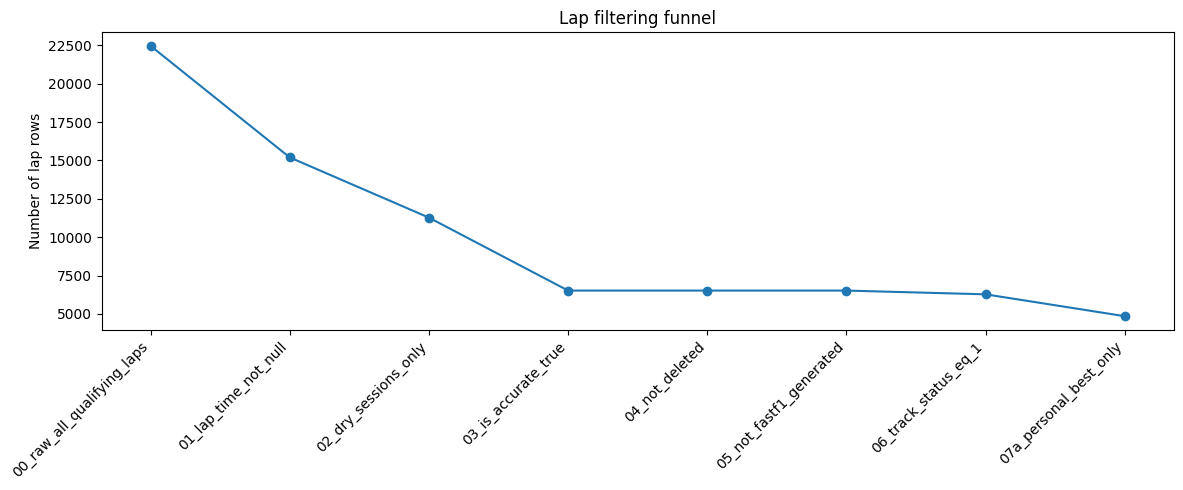

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(filter_funnel_df["step"], filter_funnel_df["n_rows"], marker="o")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of lap rows")
plt.title("Lap filtering funnel")
plt.tight_layout()
plt.show()

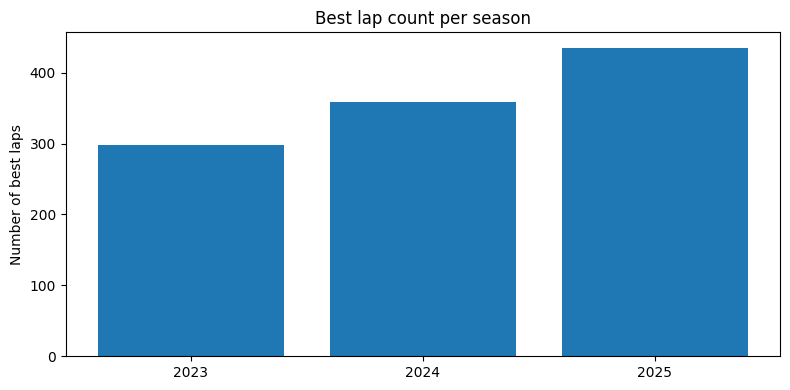

In [18]:
best_lap_counts = (
    session_driver_best_laps_df.groupby("season")
    .size()
    .reset_index(name="n_best_laps")
)

plt.figure(figsize=(8, 4))
plt.bar(best_lap_counts["season"].astype(str), best_lap_counts["n_best_laps"])
plt.ylabel("Number of best laps")
plt.title("Best lap count per season")
plt.tight_layout()
plt.show()

In [19]:
missingness_df = (
    step_06.isna()
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
missingness_df.columns = ["column", "missing_fraction"]

missingness_df.head(20)

,column,missing_fraction
0,PitOutTime,1.000000
1,Position,1.000000
2,PitInTime,1.000000
3,Deleted,1.000000
4,TyreLife,0.000796
5,Driver,0.000000
6,Time,0.000000
7,Stint,0.000000
8,LapNumber,0.000000
9,LapTime,0.000000


In [20]:
export_csv(missingness_df, "clean_laps_missingness")
print("Exported: exports/clean_laps_missingness.csv")

Exported: exports/clean_laps_missingness.csv


## Source: `03_got_the_data.ipynb`


In [1]:
from pathlib import Path
import warnings

import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

EXPORT_DIR = Path("exports")
CACHE_DIR = Path("f1_cache")
CACHE_DIR.mkdir(exist_ok=True)

fastf1.Cache.enable_cache(str(CACHE_DIR))

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
def export_csv(df: pd.DataFrame, name: str) -> Path:
    path = EXPORT_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    return path

def timed_to_seconds(series: pd.Series) -> pd.Series:
    return pd.to_timedelta(series, errors="coerce").dt.total_seconds()

def make_lap_key(df: pd.DataFrame) -> pd.Series:
    return (
        df["season"].astype(str) + "_" +
        df["round"].astype(str) + "_" +
        df["Driver"].astype(str) + "_" +
        df["LapNumber"].astype(str)
    )

In [3]:
best_laps_df = pd.read_csv(EXPORT_DIR / "session_driver_best_laps.csv")

print(best_laps_df.shape)
best_laps_df.head()

(1091, 39)


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,Sector3Time,Sector1SessionTime,Sector2SessionTime,Sector3SessionTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,IsPersonalBest,Compound,TyreLife,FreshTyre,Team,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,season,round,event_name,session_name,LapTimeSeconds,Sector1TimeSeconds,Sector2TimeSeconds,Sector3TimeSeconds,session_max_rainfall,session_is_dry_by_weather
0,0 days 00:39:56.567000,ALB,23,0 days 00:01:31.461000,5.0,2.0,NaN,NaN,0 days 00:00:29.250000,0 days 00:00:39.224000,0 days 00:00:22.987000,0 days 00:38:54.356000,0 days 00:39:33.580000,0 days 00:39:56.567000,241.0,274.0,291.0,322.0,True,SOFT,2.0,True,Williams,1,NaN,NaN,NaN,False,True,2023,1,Bahrain Grand Prix,Q,91.461,29.250,39.224,22.987,False,True
1,0 days 01:19:51.112000,ALO,14,0 days 00:01:30.336000,14.0,5.0,NaN,NaN,0 days 00:00:28.852000,0 days 00:00:38.774000,0 days 00:00:22.710000,0 days 01:18:49.628000,0 days 01:19:28.402000,0 days 01:19:51.112000,242.0,267.0,284.0,317.0,True,SOFT,2.0,True,Aston Martin,1,NaN,NaN,NaN,False,True,2023,1,Bahrain Grand Prix,Q,90.336,28.852,38.774,22.710,False,True
2,0 days 01:03:19.810000,BOT,77,0 days 00:01:31.443000,11.0,4.0,NaN,NaN,0 days 00:00:29.235000,0 days 00:00:39.327000,0 days 00:00:22.881000,0 days 01:02:17.602000,0 days 01:02:56.929000,0 days 01:03:19.810000,240.0,268.0,280.0,318.0,True,SOFT,5.0,False,Alfa Romeo,1,NaN,NaN,NaN,False,True,2023,1,Bahrain Grand Prix,Q,91.443,29.235,39.327,22.881,False,True
3,0 days 00:31:26.629000,DEV,21,0 days 00:01:32.121000,5.0,2.0,NaN,NaN,0 days 00:00:29.382000,0 days 00:00:39.634000,0 days 00:00:23.105000,0 days 00:30:23.890000,0 days 00:31:03.524000,0 days 00:31:26.629000,240.0,270.0,285.0,315.0,True,SOFT,2.0,True,AlphaTauri,1,NaN,NaN,NaN,False,True,2023,1,Bahrain Grand Prix,Q,92.121,29.382,39.634,23.105,False,True
4,0 days 00:40:47.282000,GAS,10,0 days 00:01:31.818000,5.0,2.0,NaN,NaN,0 days 00:00:29.247000,0 days 00:00:39.412000,0 days 00:00:23.159000,0 days 00:39:44.711000,0 days 00:40:24.123000,0 days 00:40:47.282000,241.0,270.0,285.0,322.0,False,SOFT,2.0,True,Alpine,1,NaN,NaN,NaN,False,True,2023,1,Bahrain Grand Prix,Q,91.818,29.247,39.412,23.159,False,True


In [4]:
best_laps_df["lap_key"] = make_lap_key(best_laps_df)

# keep only the columns we need to find and describe the laps
best_laps_base = best_laps_df[
    [
        "lap_key", "season", "round", "event_name", "Driver", "DriverNumber",
        "LapNumber", "LapTimeSeconds", "Sector1TimeSeconds",
        "Sector2TimeSeconds", "Sector3TimeSeconds",
        "Compound", "TyreLife", "Team"
    ]
].copy()

best_laps_base.head()

,lap_key,season,round,event_name,Driver,DriverNumber,LapNumber,LapTimeSeconds,Sector1TimeSeconds,Sector2TimeSeconds,Sector3TimeSeconds,Compound,TyreLife,Team
0,2023_1_ALB_5.0,2023,1,Bahrain Grand Prix,ALB,23,5.0,91.461,29.250,39.224,22.987,SOFT,2.0,Williams
1,2023_1_ALO_14.0,2023,1,Bahrain Grand Prix,ALO,14,14.0,90.336,28.852,38.774,22.710,SOFT,2.0,Aston Martin
2,2023_1_BOT_11.0,2023,1,Bahrain Grand Prix,BOT,77,11.0,91.443,29.235,39.327,22.881,SOFT,5.0,Alfa Romeo
3,2023_1_DEV_5.0,2023,1,Bahrain Grand Prix,DEV,21,5.0,92.121,29.382,39.634,23.105,SOFT,2.0,AlphaTauri
4,2023_1_GAS_5.0,2023,1,Bahrain Grand Prix,GAS,10,5.0,91.818,29.247,39.412,23.159,SOFT,2.0,Alpine


In [5]:
telemetry_rows = []
telemetry_audit_rows = []

grouped = best_laps_base.groupby(["season", "round"], sort=True)

for (season, round_number), group in grouped:
    print(f"\nLoading session {season} R{int(round_number):02d}")
    
    try:
        session = fastf1.get_session(int(season), int(round_number), "Q")
        session.load(laps=True, telemetry=True, weather=False, messages=False)
        laps = session.laps.copy()

        for _, target in group.iterrows():
            driver = target["Driver"]
            lap_number = target["LapNumber"]
            lap_key = target["lap_key"]

            try:
                candidate = laps[
                    (laps["Driver"] == driver) &
                    (laps["LapNumber"] == lap_number)
                ].copy()

                if len(candidate) != 1:
                    telemetry_audit_rows.append({
                        "lap_key": lap_key,
                        "season": season,
                        "round": round_number,
                        "Driver": driver,
                        "LapNumber": lap_number,
                        "status": "lap_match_not_unique",
                        "n_matches": len(candidate)
                    })
                    continue

                lap = candidate.iloc[0]

                car_data = lap.get_car_data().copy()
                pos_data = lap.get_pos_data().copy()

                # standardize timing columns
                if "Time" in car_data.columns:
                    car_data["telemetry_time_sec"] = timed_to_seconds(car_data["Time"])
                if "SessionTime" in car_data.columns:
                    car_data["telemetry_session_time_sec"] = timed_to_seconds(car_data["SessionTime"])
                if "Date" in car_data.columns:
                    car_data["telemetry_date"] = car_data["Date"].astype(str)

                if "Time" in pos_data.columns:
                    pos_data["pos_time_sec"] = timed_to_seconds(pos_data["Time"])
                if "SessionTime" in pos_data.columns:
                    pos_data["pos_session_time_sec"] = timed_to_seconds(pos_data["SessionTime"])
                if "Date" in pos_data.columns:
                    pos_data["pos_date"] = pos_data["Date"].astype(str)

                # attach identifiers
                for df_ in [car_data, pos_data]:
                    df_["lap_key"] = lap_key
                    df_["season"] = season
                    df_["round"] = round_number
                    df_["Driver"] = driver
                    df_["LapNumber"] = lap_number

                # add lap metadata to car data
                for col in ["LapTimeSeconds", "Sector1TimeSeconds", "Sector2TimeSeconds", "Sector3TimeSeconds", "Compound", "TyreLife", "Team"]:
                    car_data[col] = target[col]

                # rename pos columns before merge to avoid collisions
                pos_keep = [c for c in pos_data.columns if c in [
                    "lap_key", "X", "Y", "Z", "Status",
                    "pos_time_sec", "pos_session_time_sec", "pos_date"
                ]]

                pos_data = pos_data[pos_keep].copy()

                # merge using row order index as a simple first-pass alignment
                car_data = car_data.reset_index(drop=True)
                pos_data = pos_data.reset_index(drop=True)

                n = min(len(car_data), len(pos_data))
                merged = pd.concat(
                    [
                        car_data.iloc[:n].reset_index(drop=True),
                        pos_data.drop(columns=["lap_key"], errors="ignore").iloc[:n].reset_index(drop=True)
                    ],
                    axis=1
                )

                merged["sample_idx"] = np.arange(len(merged))

                telemetry_rows.append(merged)

                telemetry_audit_rows.append({
                    "lap_key": lap_key,
                    "season": season,
                    "round": round_number,
                    "Driver": driver,
                    "LapNumber": lap_number,
                    "status": "ok",
                    "car_rows": len(car_data),
                    "pos_rows": len(pos_data),
                    "merged_rows": len(merged)
                })

            except Exception as e:
                telemetry_audit_rows.append({
                    "lap_key": lap_key,
                    "season": season,
                    "round": round_number,
                    "Driver": driver,
                    "LapNumber": lap_number,
                    "status": "lap_extract_error",
                    "error_type": type(e).__name__,
                    "error_msg": str(e)
                })

    except Exception as e:
        print(f"Session failed: {season} R{int(round_number):02d} -> {type(e).__name__}: {e}")
        for _, target in group.iterrows():
            telemetry_audit_rows.append({
                "lap_key": target["lap_key"],
                "season": season,
                "round": round_number,
                "Driver": target["Driver"],
                "LapNumber": target["LapNumber"],
                "status": "session_load_error",
                "error_type": type(e).__name__,
                "error_msg": str(e)
            })

telemetry_df = pd.concat(telemetry_rows, ignore_index=True) if telemetry_rows else pd.DataFrame()
telemetry_audit_df = pd.DataFrame(telemetry_audit_rows)

print("telemetry_df shape:", telemetry_df.shape)
print("telemetry_audit_df shape:", telemetry_audit_df.shape)


Loading session 2023 R01


core           INFO 	Loading data for Bahrain Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '16', '55', '14', '63', '44', '18', '31', '27', '4', '77', '24', '22', '23', '2', '20', '81', '21', '10']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached


Loading session 2023 R02


req            INFO 	No cached data found for car_data. Loading data...
_api           INFO 	Fetching car data...
_api           INFO 	Parsing car data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for position_data. Loading data...
_api           INFO 	Fetching position data...
_api           INFO 	Parsing position data...
req            INFO 	Data has been written to cache!
core           INFO 	Finished loading data for 20 drivers: ['11', '16', '14', '63', '55', '18', '31', '44', '81', '10', '27', '24', '20', '77', '1', '22', '23', '21', '4', '2']
core           INFO 	Loading data for Azerbaijan Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req       


Loading session 2023 R04


...


Loading session 2025 R23


req            INFO 	No cached data found for car_data. Loading data...
_api           INFO 	Fetching car data...
_api           INFO 	Parsing car data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for position_data. Loading data...
_api           INFO 	Fetching position data...
_api           INFO 	Parsing position data...
req            INFO 	Data has been written to cache!
core           INFO 	Finished loading data for 20 drivers: ['81', '4', '1', '63', '12', '6', '55', '14', '10', '16', '27', '30', '87', '5', '23', '22', '31', '44', '18', '43']
core           INFO 	Loading data for Abu Dhabi Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req         


Loading session 2025 R24


req            INFO 	No cached data found for car_data. Loading data...
_api           INFO 	Fetching car data...
_api           INFO 	Parsing car data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for position_data. Loading data...
_api           INFO 	Fetching position data...
_api           INFO 	Parsing position data...
req            INFO 	Data has been written to cache!
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '81', '63', '16', '14', '5', '31', '6', '22', '87', '55', '30', '12', '18', '44', '23', '27', '10', '43']


telemetry_df shape: (339920, 33)
telemetry_audit_df shape: (1091, 9)


In [6]:
telemetry_audit_df["status"].value_counts(dropna=False)

status
ok    1091
Name: count, dtype: int64

In [7]:
success_summary = (
    telemetry_audit_df.groupby("status", dropna=False)
    .size()
    .reset_index(name="count")
)

success_summary["fraction"] = success_summary["count"] / len(telemetry_audit_df)
success_summary

,status,count,fraction
0,ok,1091,1.0


In [8]:
ok_audit = telemetry_audit_df[telemetry_audit_df["status"] == "ok"].copy()

ok_audit[["car_rows", "pos_rows", "merged_rows"]].describe()

,car_rows,pos_rows,merged_rows
count,1091.000000,1091.000000,1091.000000
mean,312.556370,319.954170,311.567369
std,36.984714,39.262136,37.057577
min,235.000000,236.000000,235.000000
25%,282.000000,287.500000,280.500000
50%,316.000000,322.000000,314.000000
75%,340.000000,350.000000,339.000000
max,476.000000,499.000000,476.000000


In [9]:
export_csv(telemetry_df, "best_laps_telemetry_merged")
export_csv(telemetry_audit_df, "best_laps_telemetry_audit")
export_csv(success_summary, "best_laps_telemetry_success_summary")

print("Exported:")
print("- exports/best_laps_telemetry_merged.csv")
print("- exports/best_laps_telemetry_audit.csv")
print("- exports/best_laps_telemetry_success_summary.csv")

Exported:
- exports/best_laps_telemetry_merged.csv
- exports/best_laps_telemetry_audit.csv
- exports/best_laps_telemetry_success_summary.csv


In [10]:
print(sorted(telemetry_df.columns.tolist()))
telemetry_df.head()

['Brake', 'Compound', 'DRS', 'Date', 'Driver', 'LapNumber', 'LapTimeSeconds', 'RPM', 'Sector1TimeSeconds', 'Sector2TimeSeconds', 'Sector3TimeSeconds', 'SessionTime', 'Source', 'Speed', 'Status', 'Team', 'Throttle', 'Time', 'TyreLife', 'X', 'Y', 'Z', 'lap_key', 'nGear', 'pos_date', 'pos_session_time_sec', 'pos_time_sec', 'round', 'sample_idx', 'season', 'telemetry_date', 'telemetry_session_time_sec', 'telemetry_time_sec']


,Date,RPM,Speed,nGear,Throttle,Brake,DRS,Source,Time,SessionTime,telemetry_time_sec,telemetry_session_time_sec,telemetry_date,lap_key,season,round,Driver,LapNumber,LapTimeSeconds,Sector1TimeSeconds,Sector2TimeSeconds,Sector3TimeSeconds,Compound,TyreLife,Team,Status,X,Y,Z,pos_time_sec,pos_session_time_sec,pos_date,sample_idx
0,2023-03-04 15:23:26.208,10924.0,296.0,8,100.0,False,12,car,0 days 00:00:00.105000,0 days 00:38:25.211000,0.105,2305.211,2023-03-04 15:23:26.208,2023_1_ALB_5.0,2023,1,ALB,5.0,91.461,29.25,39.224,22.987,SOFT,2.0,Williams,OnTrack,-372.0,1450.0,-159.0,0.136,2305.242,2023-03-04 15:23:26.239,0
1,2023-03-04 15:23:26.408,10989.0,298.0,8,100.0,False,12,car,0 days 00:00:00.305000,0 days 00:38:25.411000,0.305,2305.411,2023-03-04 15:23:26.408,2023_1_ALB_5.0,2023,1,ALB,5.0,91.461,29.25,39.224,22.987,SOFT,2.0,Williams,OnTrack,-366.0,1583.0,-159.0,0.376,2305.482,2023-03-04 15:23:26.479,1
2,2023-03-04 15:23:26.568,11016.0,300.0,8,100.0,False,12,car,0 days 00:00:00.465000,0 days 00:38:25.571000,0.465,2305.571,2023-03-04 15:23:26.568,2023_1_ALB_5.0,2023,1,ALB,5.0,91.461,29.25,39.224,22.987,SOFT,2.0,Williams,OnTrack,-356.0,1799.0,-159.0,0.656,2305.762,2023-03-04 15:23:26.759,2
3,2023-03-04 15:23:26.728,11096.0,301.0,8,100.0,False,12,car,0 days 00:00:00.625000,0 days 00:38:25.731000,0.625,2305.731,2023-03-04 15:23:26.728,2023_1_ALB_5.0,2023,1,ALB,5.0,91.461,29.25,39.224,22.987,SOFT,2.0,Williams,OnTrack,-343.0,2101.0,-159.0,0.916,2306.022,2023-03-04 15:23:27.019,3
4,2023-03-04 15:23:27.048,11095.0,302.0,8,100.0,False,12,car,0 days 00:00:00.945000,0 days 00:38:26.051000,0.945,2306.051,2023-03-04 15:23:27.048,2023_1_ALB_5.0,2023,1,ALB,5.0,91.461,29.25,39.224,22.987,SOFT,2.0,Williams,OnTrack,-332.0,2389.0,-159.0,1.356,2306.462,2023-03-04 15:23:27.459,4


In [11]:
driver_seq_counts = (
    telemetry_audit_df[telemetry_audit_df["status"] == "ok"]
    .groupby("Driver")
    .size()
    .reset_index(name="n_extracted_laps")
    .sort_values("n_extracted_laps", ascending=False)
)

driver_seq_counts.head(20)

,Driver,n_extracted_laps
0,ALB,55
1,ALO,55
9,GAS,55
11,HAM,55
16,NOR,55
19,PIA,55
21,RUS,55
26,VER,55
14,LEC,55
12,HUL,55


In [12]:
export_csv(driver_seq_counts, "best_laps_telemetry_driver_counts")
print("Exported: exports/best_laps_telemetry_driver_counts.csv")

Exported: exports/best_laps_telemetry_driver_counts.csv
